In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os  
from pathlib import Path


In [2]:
folder=Path('clips/deception_output')
csv_files=list(folder.rglob('*.csv'))


In [3]:
dfs=[]
for file in csv_files:
    temp=pd.read_csv(file)
    temp['video name']=file.name
    dfs.append(temp)

df=pd.concat(dfs, ignore_index=True)

In [4]:
df.head()

,frame,time_s,emotion,emotion_conf,deception_score,risk_level,micro_expression,masking,leakage,au_velocity,...,AU9,AU12,AU14R,AU15,AU17,AU20,AU23,AU25,AU26,video name
0,9,0.36,Surprise,24.154,33.3,MODERATE,NaN,Sadness,NaN,0.000,...,0,4.617,1.540,1.701,0.0,4.537,0,2.151,5.0,AN_WILTY_EP15_lie10_deception.csv
1,10,0.40,Surprise,24.534,20.3,MODERATE,NaN,NaN,NaN,1.422,...,0,4.228,1.659,1.594,0.0,4.284,0,3.063,5.0,AN_WILTY_EP15_lie10_deception.csv
2,11,0.44,Surprise,24.336,16.0,LOW,NaN,NaN,NaN,1.494,...,0,4.247,1.747,2.263,0.0,4.315,0,4.298,5.0,AN_WILTY_EP15_lie10_deception.csv
3,12,0.48,Surprise,24.234,13.6,LOW,NaN,NaN,NaN,1.237,...,0,4.291,1.801,3.090,0.0,4.338,0,5.000,5.0,AN_WILTY_EP15_lie10_deception.csv
4,13,0.52,Surprise,24.408,12.2,LOW,NaN,NaN,NaN,1.528,...,0,3.978,1.567,2.273,0.0,4.114,0,4.532,5.0,AN_WILTY_EP15_lie10_deception.csv


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344951 entries, 0 to 344950
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   frame             344951 non-null  int64  
 1   time_s            344951 non-null  float64
 2   emotion           344951 non-null  object 
 3   emotion_conf      344951 non-null  float64
 4   deception_score   344951 non-null  float64
 5   risk_level        344951 non-null  object 
 6   micro_expression  9240 non-null    object 
 7   masking           22238 non-null   object 
 8   leakage           9573 non-null    object 
 9   au_velocity       344951 non-null  float64
 10  brow_asymmetry    344951 non-null  float64
 11  lid_asymmetry     344951 non-null  float64
 12  mouth_asymmetry   344951 non-null  float64
 13  total_asymmetry   344951 non-null  float64
 14  AU1               344951 non-null  float64
 15  AU2               344951 non-null  float64
 16  AU4               34

In [6]:
object_cols=df.select_dtypes(include='object').columns.tolist()
numeric_cols=df.select_dtypes(exclude='object').columns.tolist()

In [7]:
object_cols

['emotion',
 'risk_level',
 'micro_expression',
 'masking',
 'leakage',
 'video name']

In [8]:
for i in object_cols:
    print(i,df[i].nunique())


emotion 4
risk_level 4
micro_expression 4
masking 2
leakage 1
video name 1453


In [9]:
for i in object_cols[:-1]:
    print(i,df[i].unique())

emotion ['Surprise' 'Fear' 'Anger' 'Contempt']
risk_level ['MODERATE' 'LOW' 'HIGH' 'ELEVATED']
micro_expression [nan 'Fear' 'Surprise' 'Anger' 'Contempt']
masking ['Sadness' nan 'Anger']
leakage [nan 'Contempt']


In [10]:
for i in object_cols[:-1]:
    print(i,df[i].isna().sum())
    print('total',df[i].count())

emotion 0
total 344951
risk_level 0
total 344951
micro_expression 335711
total 9240
masking 322713
total 22238
leakage 335378
total 9573


In [11]:
## Since both overlap we can not join two col
##both_exist=df['micro_expression'].notna() & df['leakage'].notna() 
##print('Any overlap:', both_exist.any())

<Axes: xlabel='count', ylabel='leakage'>

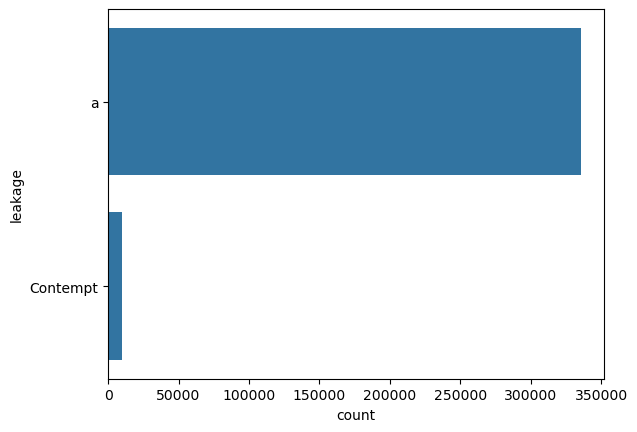

In [12]:
df['leakage']=df['leakage'].fillna('a')
df['leakage']
sns.countplot(df['leakage'])

<Axes: xlabel='count', ylabel='masking'>

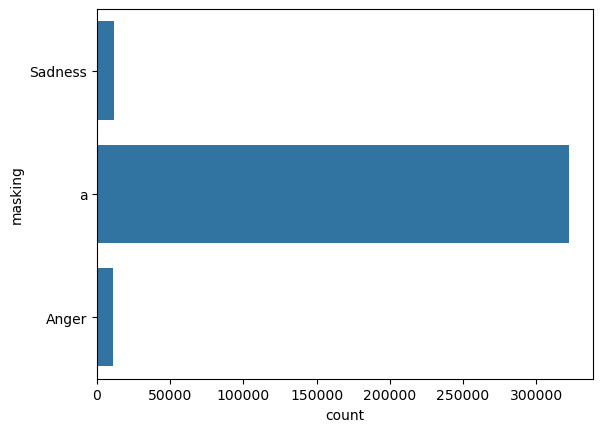

In [13]:
df['masking']=df['masking'].fillna('a')
df['masking']
sns.countplot(df['masking'])

<Axes: xlabel='count', ylabel='micro_expression'>

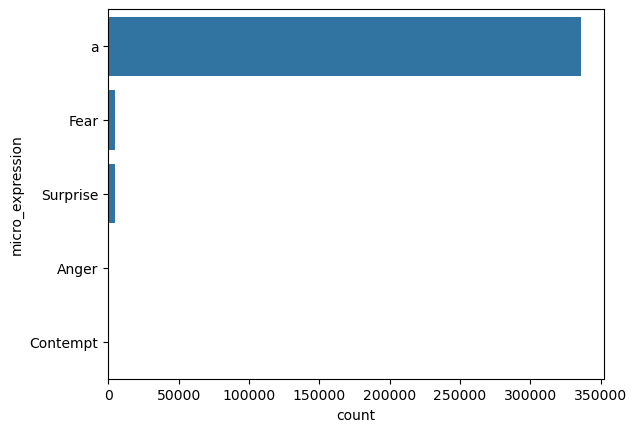

In [14]:
df['micro_expression']=df['micro_expression'].fillna('a')
df['micro_expression']
sns.countplot(df['micro_expression'])

In [15]:
object_cols

['emotion',
 'risk_level',
 'micro_expression',
 'masking',
 'leakage',
 'video name']

In [16]:
df=pd.get_dummies(df,columns=object_cols[:-1],drop_first=True,dtype=int)
df.head()

,frame,time_s,emotion_conf,deception_score,au_velocity,brow_asymmetry,lid_asymmetry,mouth_asymmetry,total_asymmetry,AU1,...,risk_level_HIGH,risk_level_LOW,risk_level_MODERATE,micro_expression_Contempt,micro_expression_Fear,micro_expression_Surprise,micro_expression_a,masking_Sadness,masking_a,leakage_a
0,9,0.36,24.154,33.3,0.000,0.131,0.210,0.770,1.111,2.5,...,0,0,1,0,0,0,1,1,0,1
1,10,0.40,24.534,20.3,1.422,0.245,0.408,0.829,1.483,2.5,...,0,0,1,0,0,0,1,0,1,1
2,11,0.44,24.336,16.0,1.494,0.446,0.163,0.873,1.482,2.5,...,0,1,0,0,0,0,1,0,1,1
3,12,0.48,24.234,13.6,1.237,0.353,0.065,0.900,1.318,2.5,...,0,1,0,0,0,0,1,0,1,1
4,13,0.52,24.408,12.2,1.528,0.342,0.099,0.783,1.225,2.5,...,0,1,0,0,0,0,1,0,1,1


In [17]:
for i in numeric_cols:
    print(i,df[i].nunique())

frame 31517
time_s 31517
emotion_conf 7031
deception_score 545
au_velocity 8406
brow_asymmetry 2244
lid_asymmetry 1871
mouth_asymmetry 5588
total_asymmetry 4964
AU1 1476
AU2 1162
AU4 2656
AU5 4595
AU6 2323
AU7 4891
AU9 1
AU12 4865
AU14R 5001
AU15 5001
AU17 24
AU20 3806
AU23 1
AU25 5001
AU26 520


In [18]:
df.drop(['frame','AU9','AU23'],axis=1,inplace=True)

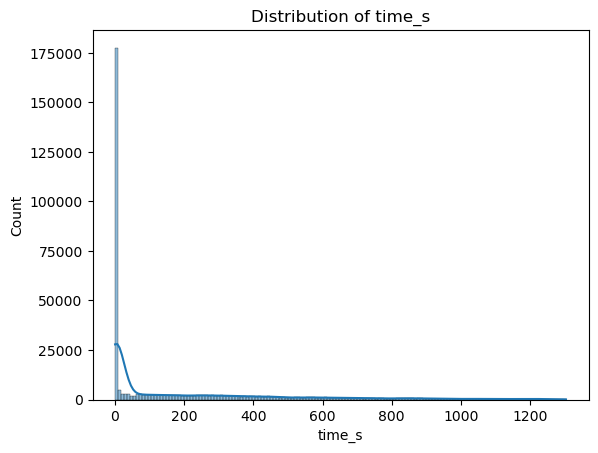

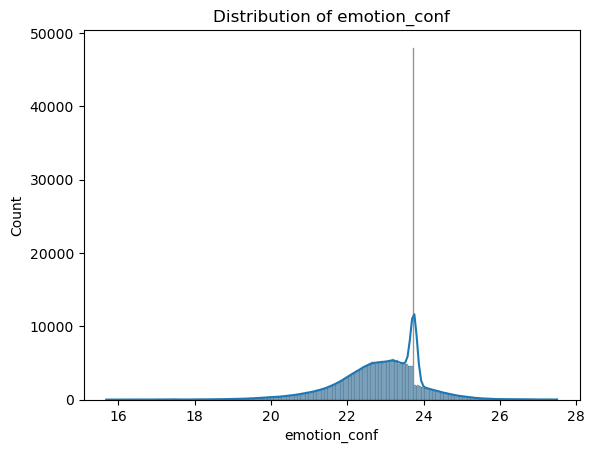

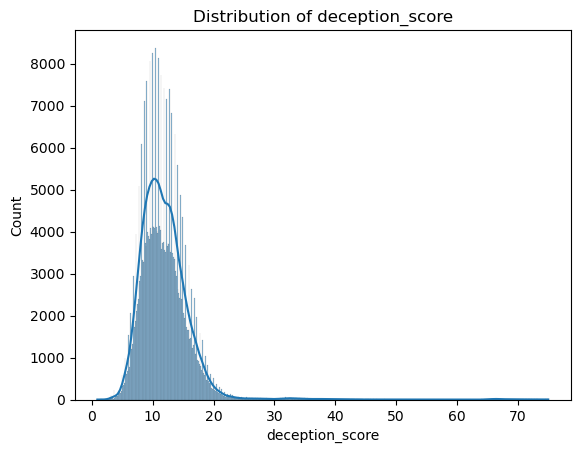

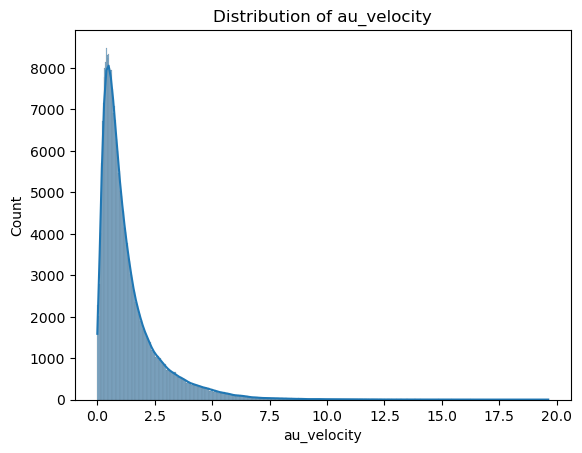

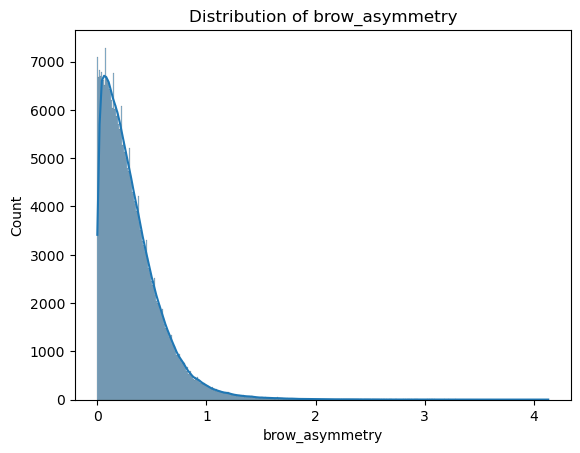

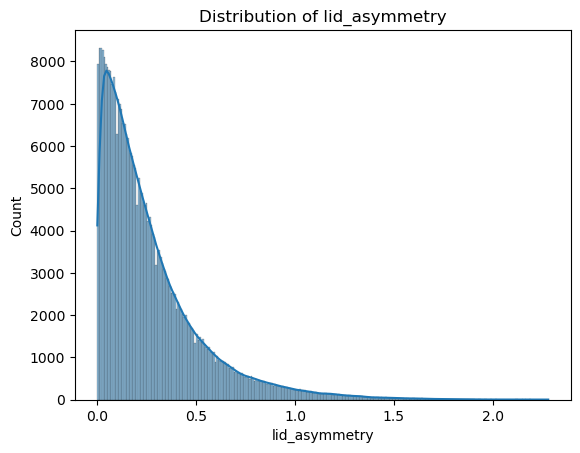

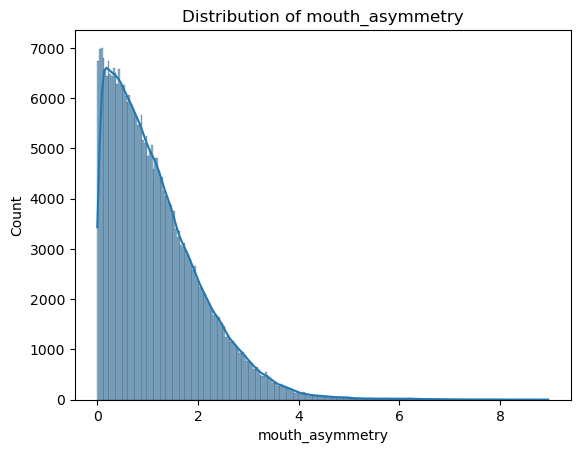

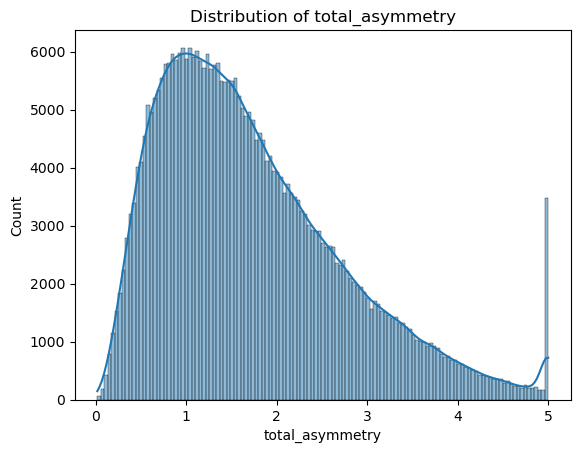

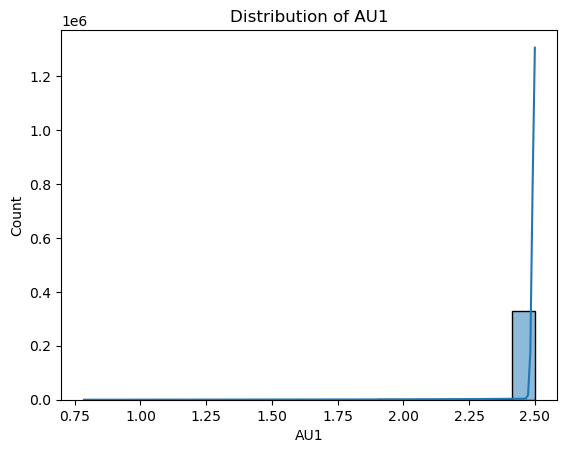

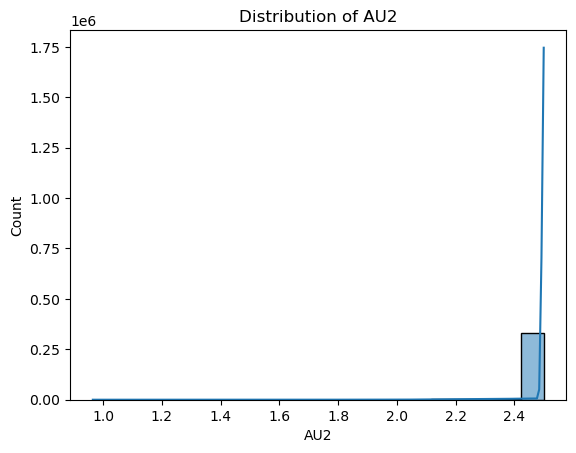

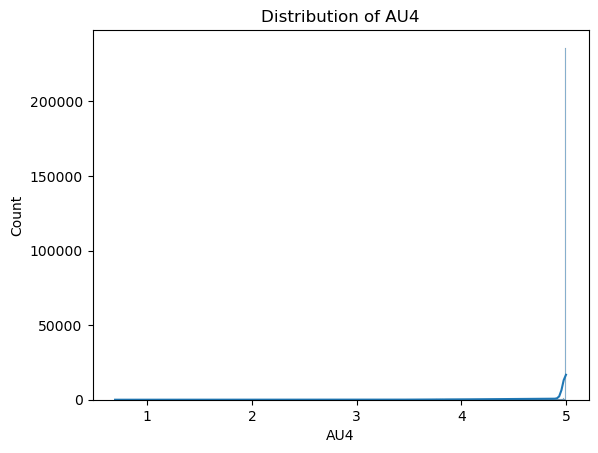

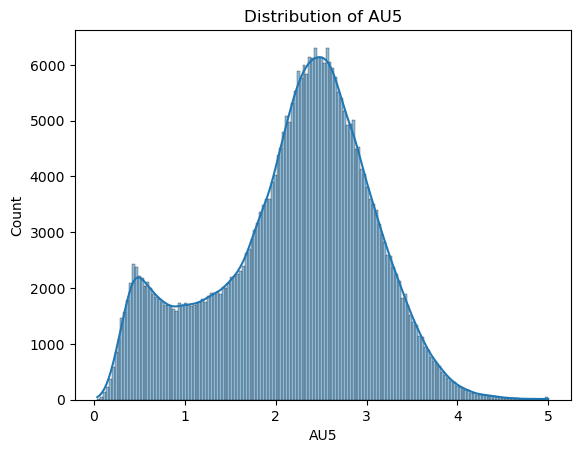

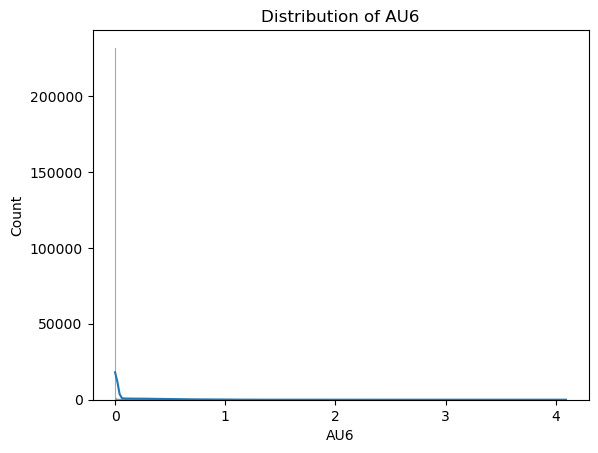

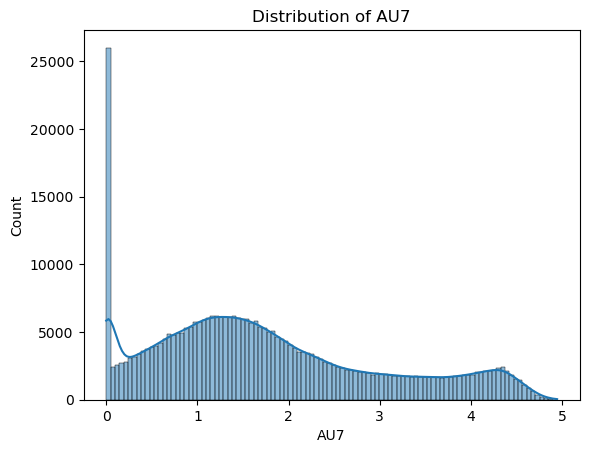

KeyError: 'AU9'

In [19]:
for col in numeric_cols[1:]:
    plt.Figure()
    sns.histplot(df[col],kde='True')
    plt.title(f'Distribution of {col}')
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344951 entries, 0 to 344950
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame                      344951 non-null  int64  
 1   time_s                     344951 non-null  float64
 2   emotion_conf               344951 non-null  float64
 3   deception_score            344951 non-null  float64
 4   au_velocity                344951 non-null  float64
 5   brow_asymmetry             344951 non-null  float64
 6   lid_asymmetry              344951 non-null  float64
 7   mouth_asymmetry            344951 non-null  float64
 8   total_asymmetry            344951 non-null  float64
 9   AU1                        344951 non-null  float64
 10  AU2                        344951 non-null  float64
 11  AU4                        344951 non-null  float64
 12  AU5                        344951 non-null  float64
 13  AU6                        34

In [ ]:
df.columns

Index(['frame', 'time_s', 'emotion_conf', 'deception_score', 'au_velocity',
       'brow_asymmetry', 'lid_asymmetry', 'mouth_asymmetry', 'total_asymmetry',
       'AU1', 'AU2', 'AU4', 'AU5', 'AU6', 'AU7', 'AU9', 'AU12', 'AU14R',
       'AU15', 'AU17', 'AU20', 'AU23', 'AU25', 'AU26', 'video name',
       'emotion_Contempt', 'emotion_Fear', 'emotion_Surprise',
       'risk_level_HIGH', 'risk_level_LOW', 'risk_level_MODERATE',
       'micro_expression_Contempt', 'micro_expression_Fear',
       'micro_expression_Surprise', 'micro_expression_a', 'masking_Sadness',
       'masking_a', 'leakage_a'],
      dtype='object')

In [20]:
cols=[ 'emotion_conf', 'deception_score', 'au_velocity','brow_asymmetry', 'lid_asymmetry', 'mouth_asymmetry', 'total_asymmetry','AU1', 'AU2', 'AU4', 'AU5', 'AU6', 'AU7', 'AU12', 'AU14R','AU15', 'AU17', 'AU20', 'AU25', 'AU26','emotion_Contempt', 'emotion_Fear', 'emotion_Surprise','risk_level_HIGH', 'risk_level_LOW', 'risk_level_MODERATE','micro_expression_Contempt', 'micro_expression_Fear',       'micro_expression_Surprise', 'micro_expression_a', 'masking_Sadness','masking_a', 'leakage_a']

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344951 entries, 0 to 344950
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   time_s                     344951 non-null  float64
 1   emotion_conf               344951 non-null  float64
 2   deception_score            344951 non-null  float64
 3   au_velocity                344951 non-null  float64
 4   brow_asymmetry             344951 non-null  float64
 5   lid_asymmetry              344951 non-null  float64
 6   mouth_asymmetry            344951 non-null  float64
 7   total_asymmetry            344951 non-null  float64
 8   AU1                        344951 non-null  float64
 9   AU2                        344951 non-null  float64
 10  AU4                        344951 non-null  float64
 11  AU5                        344951 non-null  float64
 12  AU6                        344951 non-null  float64
 13  AU7                        34

In [22]:
df.head()

,time_s,emotion_conf,deception_score,au_velocity,brow_asymmetry,lid_asymmetry,mouth_asymmetry,total_asymmetry,AU1,AU2,...,risk_level_HIGH,risk_level_LOW,risk_level_MODERATE,micro_expression_Contempt,micro_expression_Fear,micro_expression_Surprise,micro_expression_a,masking_Sadness,masking_a,leakage_a
0,0.36,24.154,33.3,0.000,0.131,0.210,0.770,1.111,2.5,2.5,...,0,0,1,0,0,0,1,1,0,1
1,0.40,24.534,20.3,1.422,0.245,0.408,0.829,1.483,2.5,2.5,...,0,0,1,0,0,0,1,0,1,1
2,0.44,24.336,16.0,1.494,0.446,0.163,0.873,1.482,2.5,2.5,...,0,1,0,0,0,0,1,0,1,1
3,0.48,24.234,13.6,1.237,0.353,0.065,0.900,1.318,2.5,2.5,...,0,1,0,0,0,0,1,0,1,1
4,0.52,24.408,12.2,1.528,0.342,0.099,0.783,1.225,2.5,2.5,...,0,1,0,0,0,0,1,0,1,1


In [23]:
df[cols].corr(numeric_only=True)

,emotion_conf,deception_score,au_velocity,brow_asymmetry,lid_asymmetry,mouth_asymmetry,total_asymmetry,AU1,AU2,AU4,...,risk_level_HIGH,risk_level_LOW,risk_level_MODERATE,micro_expression_Contempt,micro_expression_Fear,micro_expression_Surprise,micro_expression_a,masking_Sadness,masking_a,leakage_a
emotion_conf,1.000000,-0.060436,-0.180395,0.006751,-0.102757,-0.042893,-0.053488,0.236563,0.219213,0.346818,...,0.000551,0.015366,-0.015942,-0.025170,-0.057782,-0.041095,0.071118,0.006951,-0.006526,0.005978
deception_score,-0.060436,1.000000,0.050739,0.172041,0.137318,0.454166,0.477086,-0.053151,-0.070419,-0.028243,...,0.496205,-0.575999,0.452264,0.003556,0.009686,0.018627,-0.020269,0.112160,-0.139490,-0.186299
au_velocity,-0.180395,0.050739,1.000000,0.062969,0.096708,-0.034426,0.007201,0.015726,-0.004152,-0.173652,...,-0.038852,-0.013845,0.024435,-0.000549,0.036959,0.033465,-0.050128,0.033774,-0.036157,-0.070049
brow_asymmetry,0.006751,0.172041,0.062969,1.000000,0.168287,0.142713,0.422909,-0.029348,-0.013880,-0.108288,...,0.013959,-0.071562,0.069612,-0.001003,0.001380,0.002365,-0.002638,0.001579,-0.004387,-0.032467
lid_asymmetry,-0.102757,0.137318,0.096708,0.168287,1.000000,0.081544,0.362105,-0.004593,-0.008588,-0.173864,...,0.003343,-0.060339,0.061310,0.000540,0.014135,-0.000910,-0.009377,0.002842,-0.000654,-0.017167
mouth_asymmetry,-0.042893,0.454166,-0.034426,0.142713,0.081544,1.000000,0.918260,-0.204406,-0.236840,0.055917,...,0.039387,-0.153004,0.146497,0.021060,-0.011375,-0.008281,0.013294,-0.006627,0.003496,-0.135777
total_asymmetry,-0.053488,0.477086,0.007201,0.422909,0.362105,0.918260,1.000000,-0.159236,-0.173507,-0.020038,...,0.039278,-0.161276,0.155146,0.014381,-0.006157,-0.006487,0.008540,-0.004643,0.001683,-0.132003
AU1,0.236563,-0.053151,0.015726,-0.029348,-0.004593,-0.204406,-0.159236,1.000000,0.639543,-0.084704,...,0.000494,0.033896,-0.034631,-0.052014,0.009932,0.009813,-0.012434,0.027334,-0.011310,0.013415
AU2,0.219213,-0.070419,-0.004152,-0.013880,-0.008588,-0.236840,-0.173507,0.639543,1.000000,-0.084077,...,-0.004890,0.037486,-0.036275,-0.070065,0.004617,0.005852,-0.005155,0.016441,-0.007546,0.016438
AU4,0.346818,-0.028243,-0.173652,-0.108288,-0.173864,0.055917,-0.020038,-0.084704,-0.084077,1.000000,...,0.004647,0.019945,-0.021739,0.002188,-0.041448,0.001554,0.028223,-0.014414,-0.000384,0.001625


<Axes: >

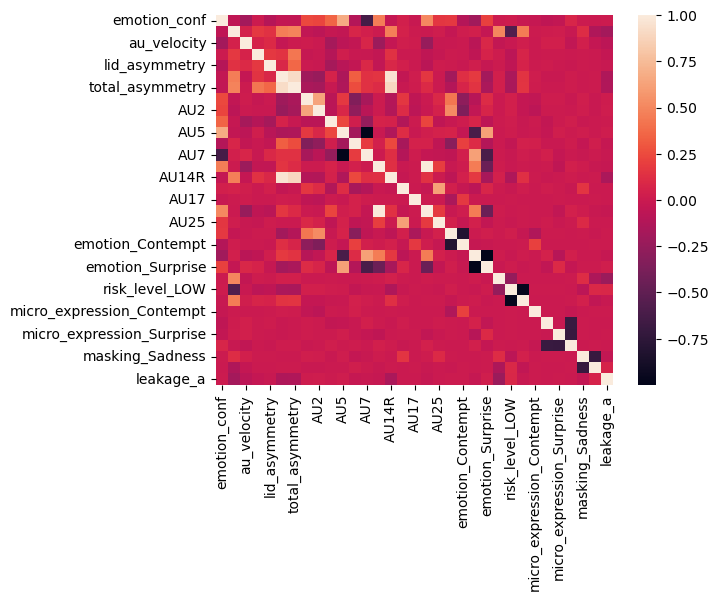

In [24]:
sns.heatmap(df[cols].corr(numeric_only=True))

In [25]:
df.to_csv('Preprocessed.csv')